## UPI Transactions 2024 : Exploratory Data Analysis

This notebook explores UPI (Unified Payments Interface) transaction data for 2024, combined with
state-level economic data and official NPCI monthly statistics.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Keep charts clean and readable
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', None)

#### Loading the Data

In [35]:
TRANSACTIONS_PATH = "UPI_Transaction_2024_Clean.csv"
MONTHLY_STATS_PATH = "monthly_stats.csv"
DIM_STATE_PATH = "dim_state.csv"

df = pd.read_csv(TRANSACTIONS_PATH)
monthly_stats = pd.read_csv(MONTHLY_STATS_PATH)
dim_state = pd.read_csv(DIM_STATE_PATH)

# Make state names consistent (Title Case) so they match the transactions table
dim_state["STATE"] = dim_state["STATE"].str.title()

# Parse the transaction timestamp into a proper datetime column
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], format='%d-%m-%Y %H:%M')

print("Transactions shape:", df.shape)
print("Monthly stats shape:", monthly_stats.shape)
print("Dim state shape:", dim_state.shape)

Transactions shape: (250000, 22)
Monthly stats shape: (12, 6)
Dim state shape: (28, 7)


### 1. Dataset Overview

In [36]:
df.head()

,TRANSACTION_ID,TIMESTAMP,TRANSACTION_TYPE,MERCHANT_CATEGORY,AMOUNT_INR,TRANSACTION_STATUS,SENDER_AGE_GROUP,RECEIVER_AGE_GROUP,SENDER_STATE,SENDER_BANK,RECEIVER_BANK,DEVICE_TYPE,NETWORK_TYPE,FRAUD_FLAG,HOUR_OF_DAY,DAY_OF_WEEK,IS_WEEKEND,MONTH,MONTH_NO,QUARTER,YEAR,MONTH_YEAR
0,TXN0000002167,2024-12-24 23:06:00,P2M,Grocery,332,SUCCESS,26-35,18-25,Tamil Nadu,Axis,SBI,Android,4G,0,23,Tuesday,0,December,12,Q4,2024,12-01-24
1,TXN0000002169,2024-12-11 19:00:00,P2M,Fuel,516,SUCCESS,46-55,18-25,West Bengal,SBI,SBI,Android,4G,0,19,Wednesday,0,December,12,Q4,2024,12-01-24
2,TXN0000002185,2024-12-17 13:18:00,P2M,Shopping,5842,SUCCESS,26-35,36-45,Delhi,ICICI,IndusInd,Android,WiFi,0,13,Tuesday,0,December,12,Q4,2024,12-01-24
3,TXN0000002198,2024-12-08 16:26:00,P2M,Food,102,SUCCESS,46-55,46-55,Delhi,Kotak,HDFC,Android,4G,0,16,Sunday,1,December,12,Q4,2024,12-01-24
4,TXN0000002199,2024-12-27 13:13:00,P2P,Grocery,427,FAILED,36-45,26-35,Uttar Pradesh,PNB,Axis,Android,4G,0,13,Friday,0,December,12,Q4,2024,12-01-24


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   TRANSACTION_ID      250000 non-null  str           
 1   TIMESTAMP           250000 non-null  datetime64[us]
 2   TRANSACTION_TYPE    250000 non-null  str           
 3   MERCHANT_CATEGORY   250000 non-null  str           
 4   AMOUNT_INR          250000 non-null  int64         
 5   TRANSACTION_STATUS  250000 non-null  str           
 6   SENDER_AGE_GROUP    250000 non-null  str           
 7   RECEIVER_AGE_GROUP  250000 non-null  str           
 8   SENDER_STATE        250000 non-null  str           
 9   SENDER_BANK         250000 non-null  str           
 10  RECEIVER_BANK       250000 non-null  str           
 11  DEVICE_TYPE         250000 non-null  str           
 12  NETWORK_TYPE        250000 non-null  str           
 13  FRAUD_FLAG          250000 non-null  int

In [38]:
print("Number of transactions:", len(df))
print("Date range covered:", df['MONTH'].unique().tolist())
print("\nColumn names:")
print(df.columns.tolist())

Number of transactions: 250000
Date range covered: ['December', 'November', 'October', 'September', 'August', 'July', 'June', 'May', 'April', 'March', 'February', 'January']

Column names:
['TRANSACTION_ID', 'TIMESTAMP', 'TRANSACTION_TYPE', 'MERCHANT_CATEGORY', 'AMOUNT_INR', 'TRANSACTION_STATUS', 'SENDER_AGE_GROUP', 'RECEIVER_AGE_GROUP', 'SENDER_STATE', 'SENDER_BANK', 'RECEIVER_BANK', 'DEVICE_TYPE', 'NETWORK_TYPE', 'FRAUD_FLAG', 'HOUR_OF_DAY', 'DAY_OF_WEEK', 'IS_WEEKEND', 'MONTH', 'MONTH_NO', 'QUARTER', 'YEAR', 'MONTH_YEAR']


### 2. Descriptive Statistics

Summary statistics for the numeric fields, plus a look at how transaction amounts are distributed.

In [39]:
df[['AMOUNT_INR', 'HOUR_OF_DAY']].describe()

,AMOUNT_INR,HOUR_OF_DAY
count,250000.000000,250000.000000
mean,1311.756036,14.681032
std,1848.059224,5.188304
min,10.000000,0.000000
25%,288.000000,11.000000
50%,629.000000,15.000000
75%,1596.000000,19.000000
max,42099.000000,23.000000


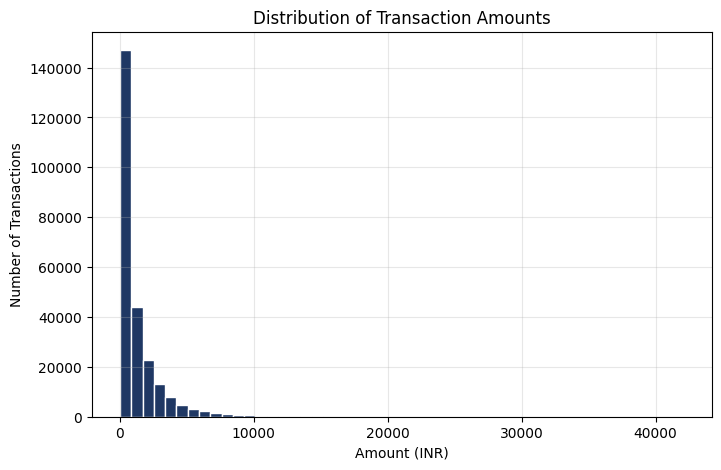

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(df['AMOUNT_INR'], bins=50, color="#1F3864", edgecolor='white')
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount (INR)")
plt.ylabel("Number of Transactions")
plt.show()

### 3. Monthly Trends

Transaction volume and value across the year, sorted by actual month order.

In [41]:
monthly_summary = df.groupby(['MONTH_NO', 'MONTH']).agg(
    total_transactions=('TRANSACTION_ID', 'count'),
    total_amount=('AMOUNT_INR', 'sum')
).reset_index().sort_values('MONTH_NO')

monthly_summary

,MONTH_NO,MONTH,total_transactions,total_amount
0,1,January,21221,27456691
1,2,February,19759,25826330
2,3,March,21234,27508202
3,4,April,20536,26988791
4,5,May,21333,28024857
5,6,June,20628,27032118
6,7,July,21207,28079905
7,8,August,21231,27845907
8,9,September,20597,27105761
9,10,October,21252,27866829


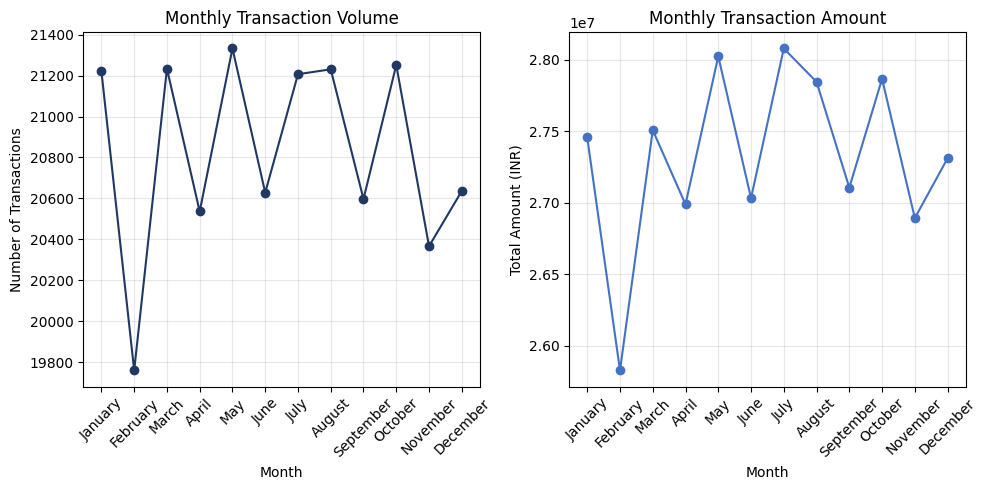

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(monthly_summary['MONTH'], monthly_summary['total_transactions'],
             marker='o', color="#1F3864")
axes[0].set_title("Monthly Transaction Volume")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Transactions")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_summary['MONTH'], monthly_summary['total_amount'],
             marker='o', color="#4472C4")
axes[1].set_title("Monthly Transaction Amount")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Amount (INR)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

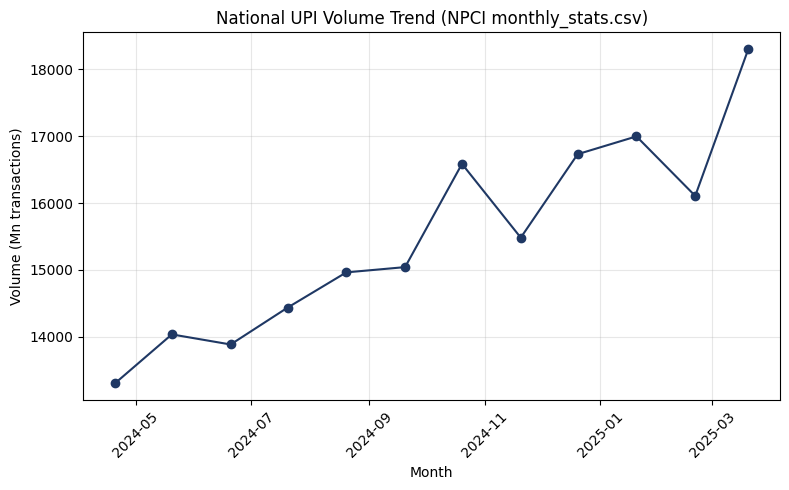

In [43]:
#  NPCI national trend from monthly_stats.csv
ms = monthly_stats.copy()
ms['MONTH_DT'] = pd.to_datetime(ms['MONTH'], format='%d-%m-%y')
ms = ms.sort_values('MONTH_DT')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(ms['MONTH_DT'], ms['VOLUME_IN_MN'], marker='o', color="#1F3864")
ax1.set_title("National UPI Volume Trend (NPCI monthly_stats.csv)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Volume (Mn transactions)")
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4. Transaction Type Analysis

In [44]:
type_summary = df.groupby('TRANSACTION_TYPE').agg(
    total_transactions=('TRANSACTION_ID', 'count'),
    avg_amount=('AMOUNT_INR', 'mean')
).sort_values('total_transactions', ascending=False)

type_summary

,total_transactions,avg_amount
TRANSACTION_TYPE,,
P2P,112445,1308.681115
P2M,87660,1320.072633
Bill Payment,37368,1308.492373
Recharge,12527,1290.895745


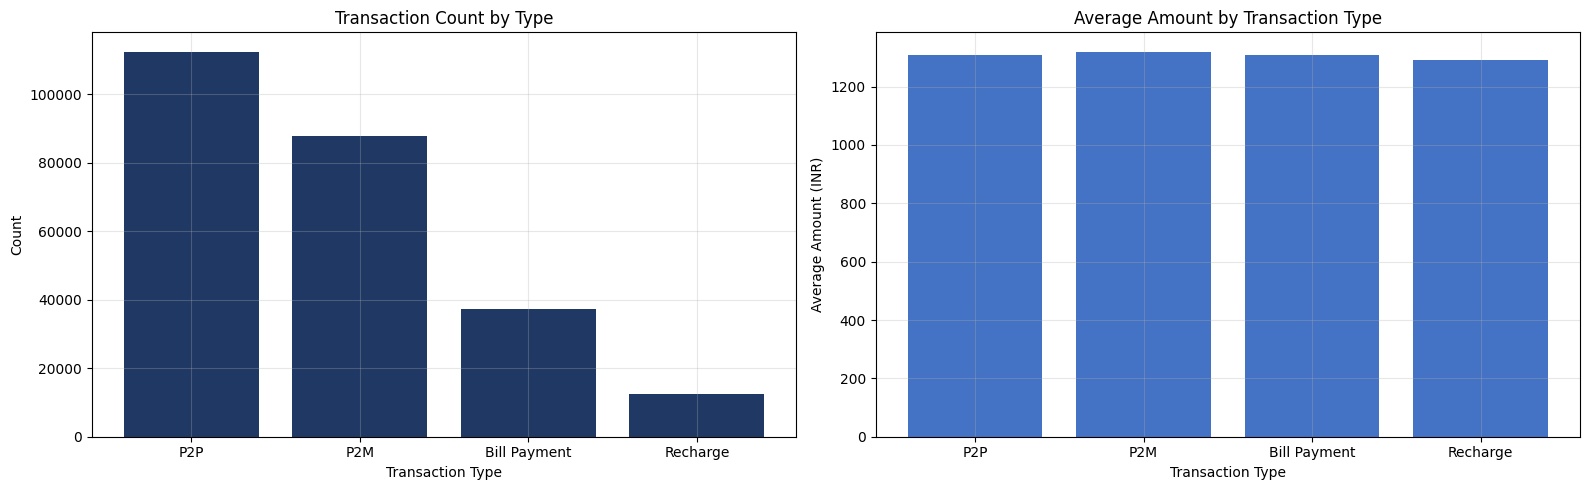

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(type_summary.index, type_summary['total_transactions'], color="#1F3864")
axes[0].set_title("Transaction Count by Type")
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Count")

axes[1].bar(type_summary.index, type_summary['avg_amount'], color="#4472C4")
axes[1].set_title("Average Amount by Transaction Type")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Average Amount (INR)")

plt.tight_layout()
plt.show()

### 5. Merchant Category Analysis

In [46]:
category_summary = df.groupby('MERCHANT_CATEGORY').agg(
    total_transactions=('TRANSACTION_ID', 'count'),
    total_amount=('AMOUNT_INR', 'sum')
).sort_values('total_amount', ascending=False)

category_summary

,total_transactions,total_amount
MERCHANT_CATEGORY,,
Shopping,29872,76863207
Grocery,49966,58277893
Utilities,22338,52742482
Fuel,25063,38982575
Education,7598,38704346
Other,24828,21073449
Food,37464,19919402
Entertainment,20103,8309080
Healthcare,12663,6874159


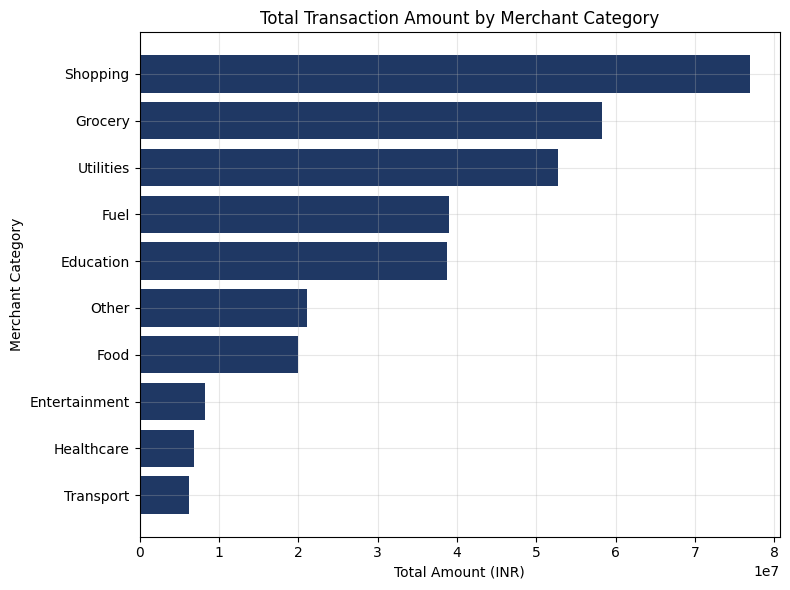

In [47]:
plt.figure(figsize=(8, 6))
plt.barh(category_summary.index[::-1], category_summary['total_amount'][::-1], color="#1F3864")
plt.title("Total Transaction Amount by Merchant Category")
plt.xlabel("Total Amount (INR)")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

### 6. Device & Network Analysis

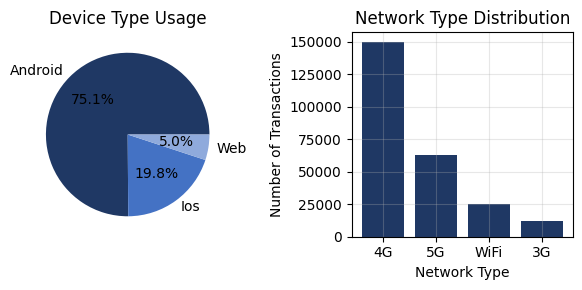

In [68]:
device_counts = df['DEVICE_TYPE'].value_counts()
network_counts = df['NETWORK_TYPE'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].pie(device_counts, labels=device_counts.index, autopct='%1.1f%%',
            colors=["#1F3864", "#4472C4", "#8FAADC"])
axes[0].set_title("Device Type Usage")

axes[1].bar(network_counts.index, network_counts.values, color="#1F3864")
axes[1].set_title("Network Type Distribution")
axes[1].set_xlabel("Network Type")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### 7. Bank Analysis

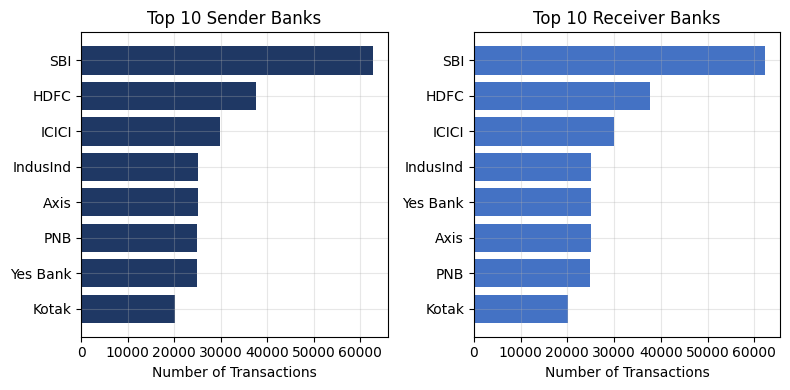

In [65]:
top_sender_banks = df['SENDER_BANK'].value_counts().head(10)
top_receiver_banks = df['RECEIVER_BANK'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].barh(top_sender_banks.index[::-1], top_sender_banks.values[::-1], color="#1F3864")
axes[0].set_title("Top 10 Sender Banks")
axes[0].set_xlabel("Number of Transactions")

axes[1].barh(top_receiver_banks.index[::-1], top_receiver_banks.values[::-1], color="#4472C4")
axes[1].set_title("Top 10 Receiver Banks")
axes[1].set_xlabel("Number of Transactions")

plt.tight_layout()
plt.show()

### 8. State Analysis

In [50]:
state_summary = df.groupby('SENDER_STATE').agg(
    total_transactions=('TRANSACTION_ID', 'count'),
    total_amount=('AMOUNT_INR', 'sum')
).sort_values('total_transactions', ascending=False).reset_index()

state_summary

,SENDER_STATE,total_transactions,total_amount
0,Maharashtra,37427,49043948
1,Uttar Pradesh,30125,40035717
2,Karnataka,29756,38451158
3,Tamil Nadu,25367,33343518
4,Delhi,24870,32689865
5,Telangana,22435,29750930
6,Gujarat,20061,25988190
7,Andhra Pradesh,20006,25952619
8,Rajasthan,19981,26730470
9,West Bengal,19972,25952594


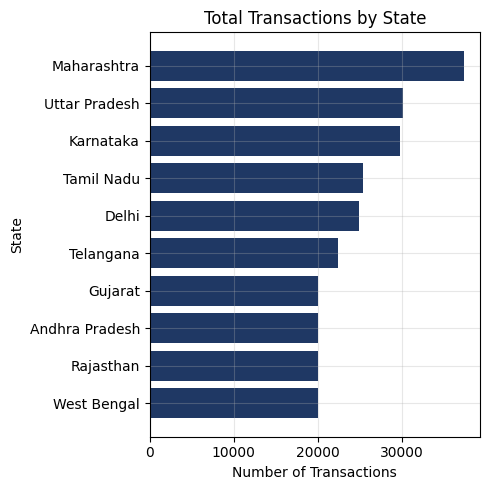

In [69]:
plt.figure(figsize=(5, 5))
plot_order = state_summary.sort_values('total_transactions')
plt.barh(plot_order['SENDER_STATE'], plot_order['total_transactions'], color="#1F3864")
plt.title("Total Transactions by State")
plt.xlabel("Number of Transactions")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [52]:
# Merge with dim_state to bring in population, then normalize transaction volume per lakh (100,000) people
state_merged = state_summary.merge(dim_state, left_on='SENDER_STATE', right_on='STATE', how='left')
state_merged['transactions_per_lakh_population'] = (
    state_merged['total_transactions'] / (state_merged['TOTAL_POPULATION'] / 100000)
)
state_merged = state_merged.sort_values('transactions_per_lakh_population', ascending=False)

state_merged[['SENDER_STATE', 'total_transactions', 'TOTAL_POPULATION', 'transactions_per_lakh_population']]

,SENDER_STATE,total_transactions,TOTAL_POPULATION,transactions_per_lakh_population
8,Rajasthan,19981,10443016,191.333615
2,Karnataka,29756,15799896,188.330354
4,Delhi,24870,13481997,184.468221
3,Tamil Nadu,25367,13879395,182.767332
1,Uttar Pradesh,30125,25302925,119.057382
6,Gujarat,20061,17835049,112.480768
9,West Bengal,19972,18063509,110.565450
7,Andhra Pradesh,20006,18171615,110.094782
0,Maharashtra,37427,37722136,99.217605
5,Telangana,22435,35003674,64.093272


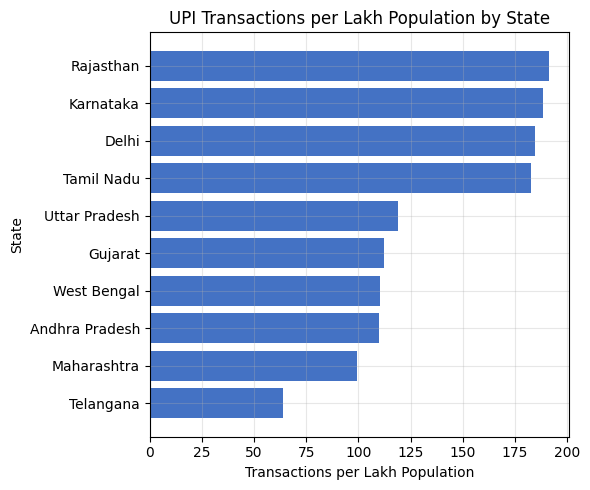

In [70]:
plt.figure(figsize=(6, 5))
plot_order = state_merged.sort_values('transactions_per_lakh_population')
plt.barh(plot_order['SENDER_STATE'], plot_order['transactions_per_lakh_population'], color="#4472C4")
plt.title("UPI Transactions per Lakh Population by State")
plt.xlabel("Transactions per Lakh Population")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### 9. Fraud Analysis

In [54]:
total_transactions = len(df)
fraud_transactions = df['FRAUD_FLAG'].sum()
fraud_rate = fraud_transactions / total_transactions

print(f"Total transactions: {total_transactions:,}")
print(f"Fraud transactions: {fraud_transactions:,}")
print(f"Fraud rate: {fraud_rate:.2%}")

Total transactions: 250,000
Fraud transactions: 480
Fraud rate: 0.19%


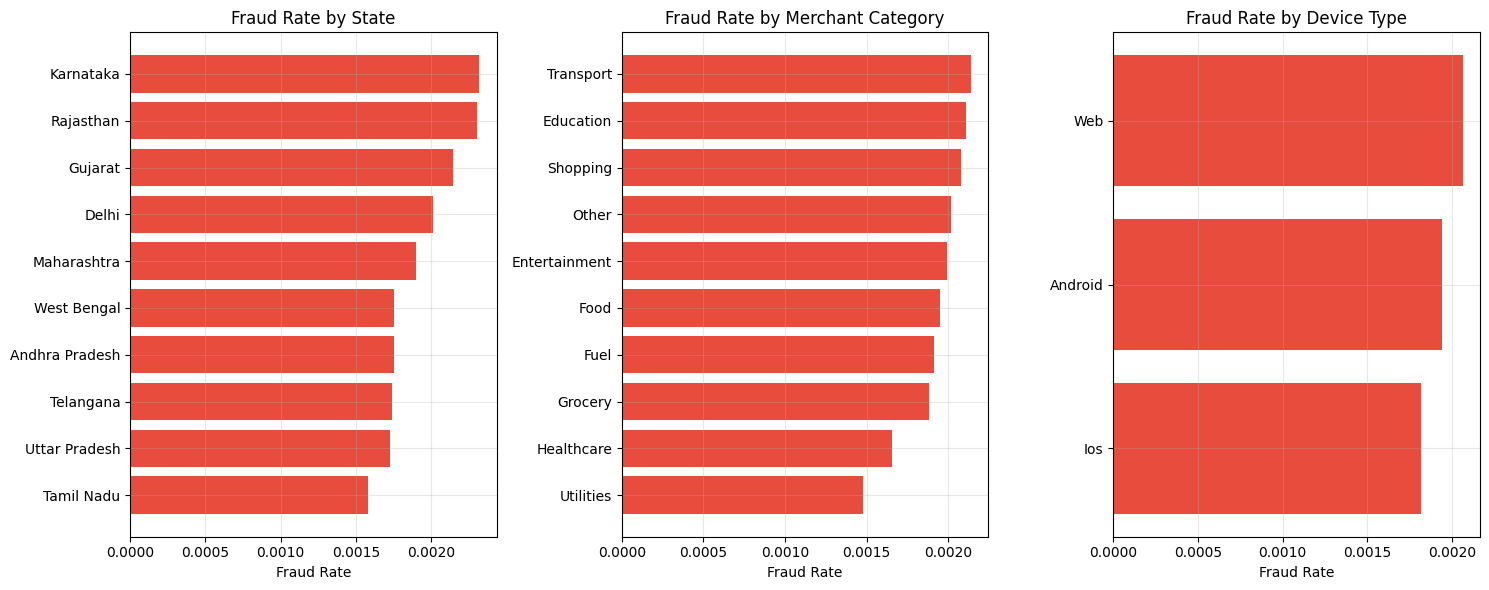

In [55]:
fraud_by_state = df.groupby('SENDER_STATE')['FRAUD_FLAG'].mean().sort_values(ascending=False)
fraud_by_category = df.groupby('MERCHANT_CATEGORY')['FRAUD_FLAG'].mean().sort_values(ascending=False)
fraud_by_device = df.groupby('DEVICE_TYPE')['FRAUD_FLAG'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].barh(fraud_by_state.index[::-1], fraud_by_state.values[::-1], color="#E74C3C")
axes[0].set_title("Fraud Rate by State")
axes[0].set_xlabel("Fraud Rate")

axes[1].barh(fraud_by_category.index[::-1], fraud_by_category.values[::-1], color="#E74C3C")
axes[1].set_title("Fraud Rate by Merchant Category")
axes[1].set_xlabel("Fraud Rate")

axes[2].barh(fraud_by_device.index[::-1], fraud_by_device.values[::-1], color="#E74C3C")
axes[2].set_title("Fraud Rate by Device Type")
axes[2].set_xlabel("Fraud Rate")

plt.tight_layout()
plt.show()

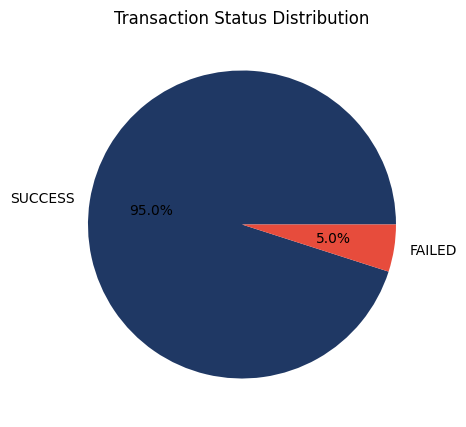

In [56]:
# Success vs Failed transaction split
status_counts = df['TRANSACTION_STATUS'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=["#1F3864", "#E74C3C"])
plt.title("Transaction Status Distribution")
plt.show()

### 10. Age Group Analysis

In [57]:
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
age_summary = df.groupby('SENDER_AGE_GROUP').agg(
    total_transactions=('TRANSACTION_ID', 'count'),
    avg_amount=('AMOUNT_INR', 'mean')
)

# Reindex to enforce logical age order (only keep groups that actually exist in the data)
existing_order = [g for g in age_order if g in age_summary.index]
age_summary = age_summary.reindex(existing_order)

age_summary

,total_transactions,avg_amount
SENDER_AGE_GROUP,,
18-25,62345,1194.545449
26-35,87432,1326.285239
36-45,62873,1424.041242
46-55,24841,1333.129141
56+,12509,1187.568631


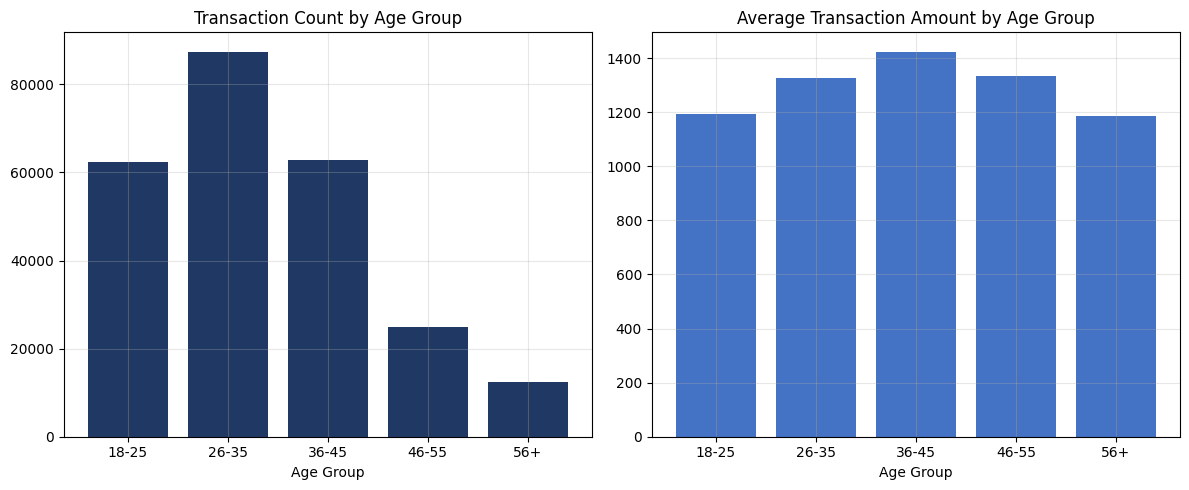

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(age_summary.index, age_summary['total_transactions'], color="#1F3864")
axes[0].set_title("Transaction Count by Age Group")
axes[0].set_xlabel("Age Group")

axes[1].bar(age_summary.index, age_summary['avg_amount'], color="#4472C4")
axes[1].set_title("Average Transaction Amount by Age Group")
axes[1].set_xlabel("Age Group")

plt.tight_layout()
plt.show()

### 11. Correlation Heatmap

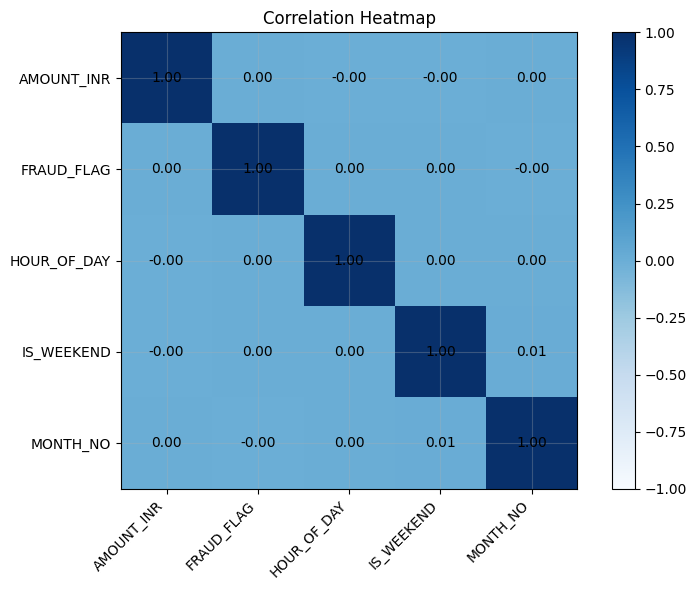

In [59]:
numeric_cols = ['AMOUNT_INR', 'FRAUD_FLAG', 'HOUR_OF_DAY', 'IS_WEEKEND', 'MONTH_NO']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr_matrix, cmap='Blues', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Note:** A low correlation means fraud does not have a strong relationship with transaction amount or timing. It may still occur more often in specific states, categories, or device types, so those are analyzed separately.

### 12. Outlier Detection

Using the IQR (Interquartile Range) method to flag unusually large transaction amounts.

In [60]:
Q1 = df['AMOUNT_INR'].quantile(0.25)
Q3 = df['AMOUNT_INR'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AMOUNT_INR'] < lower_bound) | (df['AMOUNT_INR'] > upper_bound)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outlier transactions: {len(outliers)}")
print(f"Percentage of total: {len(outliers)/len(df):.2%}")

Q1: 288.0, Q3: 1596.0, IQR: 1308.0
Lower bound: -1674.0, Upper bound: 3558.0
Number of outlier transactions: 21171
Percentage of total: 8.47%


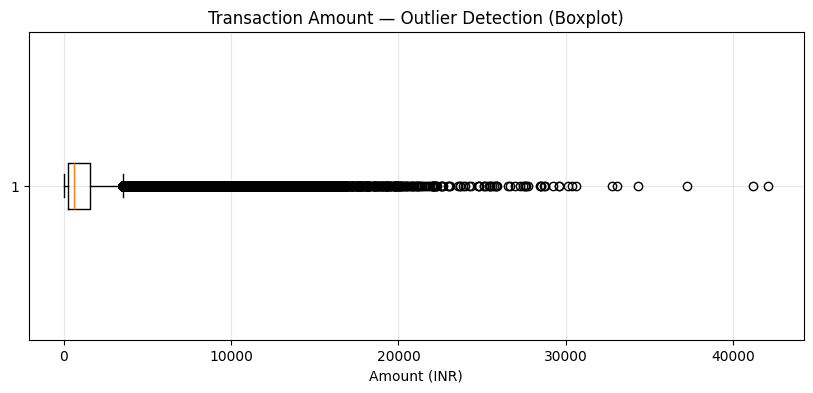

In [61]:
plt.figure(figsize=(10, 4))
plt.boxplot(df['AMOUNT_INR'], vert=False)
plt.title("Transaction Amount — Outlier Detection (Boxplot)")
plt.xlabel("Amount (INR)")
plt.show()

In [62]:
# Are outlier (high-value) transactions more or less likely to be fraudulent?
outlier_fraud_rate = outliers['FRAUD_FLAG'].mean()
normal_fraud_rate = df[~df.index.isin(outliers.index)]['FRAUD_FLAG'].mean()

print(f"Fraud rate among outlier (unusually large) transactions: {outlier_fraud_rate:.2%}")
print(f"Fraud rate among normal transactions: {normal_fraud_rate:.2%}")

Fraud rate among outlier (unusually large) transactions: 0.27%
Fraud rate among normal transactions: 0.18%


## 13. Business Insights

Key findings pulled directly from the analysis above.

In [63]:
total_transactions = len(df)

top_month = monthly_summary.loc[monthly_summary['total_transactions'].idxmax(), 'MONTH']
top_type = type_summary.index[0]
top_category = category_summary.index[0]
top_device = device_counts.index[0]
top_state = state_summary.iloc[0]['SENDER_STATE']
top_age_group = age_summary['total_transactions'].idxmax()
success_rate = (df['TRANSACTION_STATUS'] == 'SUCCESS').mean()
fraud_rate = df['FRAUD_FLAG'].mean()

print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"1. Highest transaction month: {top_month}")
print(f"2. Most used transaction type: {top_type}")
print(f"3. Top merchant category by spend: {top_category}")
print(f"4. Dominant device type: {top_device} ({device_counts.iloc[0]/total_transactions:.1%} of transactions)")
print(f"5. Highest transaction volume state: {top_state}")
print(f"6. Most active age group: {top_age_group}")
print(f"7. Overall success rate: {success_rate:.2%}")
print(f"8. Overall fraud rate: {fraud_rate:.2%}")
print(f"9. Outlier (high-value) transactions make up {len(outliers)/total_transactions:.2%} of all transactions")
print(f"10. UPI adoption is concentrated — the top state ({top_state}) accounts for {state_summary.iloc[0]['total_transactions']/total_transactions:.1%} of all transactions")

KEY BUSINESS INSIGHTS
1. Highest transaction month: May
2. Most used transaction type: P2P
3. Top merchant category by spend: Shopping
4. Dominant device type: Android (75.1% of transactions)
5. Highest transaction volume state: Maharashtra
6. Most active age group: 26-35
7. Overall success rate: 95.05%
8. Overall fraud rate: 0.19%
9. Outlier (high-value) transactions make up 8.47% of all transactions
10. UPI adoption is concentrated — the top state (Maharashtra) accounts for 15.0% of all transactions


## 14. Conclusion

This analysis shows that UPI transactions are mainly Person-to-Merchant (P2M) and Person-to-Person (P2P), with Android being the most used device. Most transactions come from economically strong states. The overall success rate is high, and fraud is very low. However, fraud is more common in some states and merchant categories, so these areas should be monitored closely.

The correlation analysis shows that fraud is not strongly related to transaction amount, time, or weekends. Instead, fraud patterns are better understood by analyzing state, merchant category, and device type.